# NETW504 - Random Signals and Noise
## Milestone 1: Exploratory Data Analysis (EDA)
- **Instructor:** Prof. Talal Elshabrawy
- **Team Name:** Hloz
- **Student Name:** Mazen Mohamed Hamdy Altelbany (ID: 64-12371)

---
### Goal of this Milestone:
Perform basic Exploratory Data Analysis (EDA) on our approved dataset (Bank Customer Churn), visualize distributions (PDF and CDF), check data quality, and apply basic preprocessing steps.


## 1. Dataset and Target

- **Dataset Name:** Bank Customer Churn Prediction
- **Kaggle Link:** [https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction](https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction)
- **Row Meaning:** Each row represents one bank customer, including their personal demographics, account balance, credit info, and whether they stayed with the bank or left.
- **Target Column:** `Exited` (1 = Customer left the bank, 0 = Customer stayed with the bank).


In [1]:
# Import the required libraries
import pandas as pd            # Used for data manipulation and loading CSV files
import numpy as np             # Used for numerical calculations and arrays
import matplotlib.pyplot as plt # Used for plotting graphs
import seaborn as sns          # Used for styled data visualization

# Set a clean plot style
sns.set_theme(style="whitegrid")

# Load the dataset from the CSV file
df = pd.read_csv('../data set/Churn_Modelling.csv')

# Print the size of the dataset (rows and columns)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Count how many customers stayed (0) and how many left (1)
target_counts = df['Exited'].value_counts()

# Calculate the percentage of each class
target_percentages = df['Exited'].value_counts(normalize=True) * 100

# Put them together into a neat summary table
target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_percentages.round(2)
})

# Display the summary table
print("\nTarget Class Summary:")
display(target_summary)


Number of rows: 10000
Number of columns: 14

Target Class Summary:


,Count,Percentage (%)
Exited,,
0,7963,79.63
1,2037,20.37


### Feature Types and ID Columns

- **ID-like Columns (To be removed later):**
  - `RowNumber`: Just the row index.
  - `CustomerId`: Random customer ID number.
  - `Surname`: Customer last name (free text).
- **Numerical Features (8):**
  - `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`.
- **Categorical Features (2):**
  - `Geography` (Country: France, Spain, Germany)
  - `Gender` (Female, Male)


In [2]:
# Create a table showing each column and its type
feature_table = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Feature Type': [
        'ID Column (Drop)', 'ID Column (Drop)', 'ID Column (Drop)',
        'Numerical', 'Categorical', 'Categorical',
        'Numerical', 'Numerical', 'Numerical',
        'Numerical', 'Numerical (Binary)', 'Numerical (Binary)',
        'Numerical', 'Target'
    ]
})

# Display the feature classification table
display(feature_table)


,Column Name,Data Type,Feature Type
0,RowNumber,int64,ID Column (Drop)
1,CustomerId,int64,ID Column (Drop)
2,Surname,str,ID Column (Drop)
3,CreditScore,int64,Numerical
4,Geography,str,Categorical
5,Gender,str,Categorical
6,Age,int64,Numerical
7,Tenure,int64,Numerical
8,Balance,float64,Numerical
9,NumOfProducts,int64,Numerical


## 2. Initial Inspection and Data Quality

Here we look at the first 5 rows, check for duplicate rows, check for missing values, and print numerical statistics.


In [3]:
# Display the first 5 rows of the dataset
print("First 5 rows:")
display(df.head())

# Show column data types and non-null counts
print("\nDataset Info:")
df.info()


First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
# Check for exact duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Count missing (null) values in every column
missing_counts = df.isnull().sum()

# Calculate missing value percentages
missing_percent = (missing_counts / len(df)) * 100

# Put missing values into a table
missing_table = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing (%)': missing_percent
})

# Display missing values table
print("\nMissing Values per Column:")
display(missing_table)


Number of duplicate rows: 0

Missing Values per Column:


,Missing Count,Missing (%)
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


### Numerical Features Statistics
We calculate: `count`, `mean`, `standard deviation`, `min`, `median`, and `max`.


In [5]:
# List of the 8 numerical input features
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]

# Calculate the required summary statistics
stats_table = pd.DataFrame({
    'count': df[numerical_features].count(),
    'mean': df[numerical_features].mean().round(2),
    'std': df[numerical_features].std().round(2),
    'min': df[numerical_features].min().round(2),
    'median': df[numerical_features].median().round(2),
    'max': df[numerical_features].max().round(2)
})

# Display the statistics table
print("Numerical Features Descriptive Statistics:")
display(stats_table)


Numerical Features Descriptive Statistics:


,count,mean,std,min,median,max
CreditScore,10000,650.53,96.65,350.00,652.00,850.00
Age,10000,38.92,10.49,18.00,37.00,92.00
Tenure,10000,5.01,2.89,0.00,5.00,10.00
Balance,10000,76485.89,62397.41,0.00,97198.54,250898.09
NumOfProducts,10000,1.53,0.58,1.00,1.00,4.00
HasCrCard,10000,0.71,0.46,0.00,1.00,1.00
IsActiveMember,10000,0.52,0.50,0.00,1.00,1.00
EstimatedSalary,10000,100090.24,57510.49,11.58,100193.92,199992.48


### Comments on Data Quality:
- **Class Balance:** The target is moderately imbalanced. Around 79.6% stayed (`0`) and 20.4% exited (`1`).
- **Duplicates and Missing Values:** There are 0 duplicate rows and 0 missing values in any column. The data is complete and clean.
- **Unusual Values:** Over 36% of customers have an account balance of 0, which makes the `Balance` distribution bimodal. `Age` has a slight right skew with some older customers up to 92 years old.


## 3. Required EDA Plots
Every plot group below has a clear title, labeled axes, and a 1–3 sentence observation.


### 3.1 Target Distribution Plot

C:\Users\Mazen\AppData\Local\Temp\ipykernel_29320\1495317242.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['0 (Stayed)', '1 (Exited)'], y=target_counts.values, palette=['#3274a1', '#e1812c'])


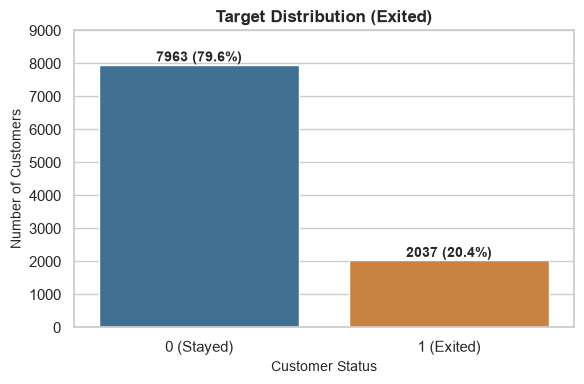

In [6]:
# Create a figure for the target distribution
plt.figure(figsize=(6, 4))

# Plot a bar chart for Exited (0 vs 1)
ax = sns.barplot(x=['0 (Stayed)', '1 (Exited)'], y=target_counts.values, palette=['#3274a1', '#e1812c'])

# Set plot title and axis labels
plt.title("Target Distribution (Exited)", fontsize=12, fontweight='bold')
plt.xlabel("Customer Status", fontsize=10)
plt.ylabel("Number of Customers", fontsize=10)

# Add text labels on top of the bars showing count and percentage
for i, count in enumerate(target_counts.values):
    pct = (count / len(df)) * 100
    ax.text(i, count + 100, f"{count} ({pct:.1f}%)", ha='center', fontsize=10, fontweight='bold')

# Give some extra space on y-axis
plt.ylim(0, 9000)
plt.tight_layout()
plt.show()


> **Observation (Target Distribution):**  
> Around 79.6% of the customers stayed with the bank while 20.4% left. This shows an imbalanced dataset (~4 to 1 ratio), so accuracy alone will not be enough to evaluate our future models.


### 3.2 Missing Values Plot

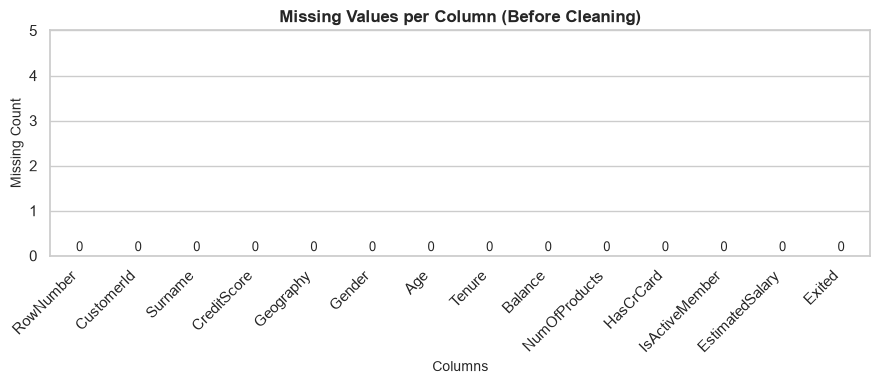

In [7]:
# Create a figure for the missing values
plt.figure(figsize=(9, 4))

# Bar plot of missing counts across all columns
ax = sns.barplot(x=missing_counts.index, y=missing_counts.values, color='#3274a1')

# Set titles and labels
plt.title("Missing Values per Column (Before Cleaning)", fontsize=12, fontweight='bold')
plt.xlabel("Columns", fontsize=10)
plt.ylabel("Missing Count", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5)

# Show count above each bar
for i, count in enumerate(missing_counts.values):
    ax.text(i, count + 0.1, str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


> **Observation (Missing Values):**  
> All columns in the dataset have exactly zero missing values. This means no rows or columns need to be dropped or imputed due to missing data.


### 3.3 Numerical Features – Estimated PDF
Normalized histogram (`stat="density"`) with a KDE curve for each of the 8 numerical features.


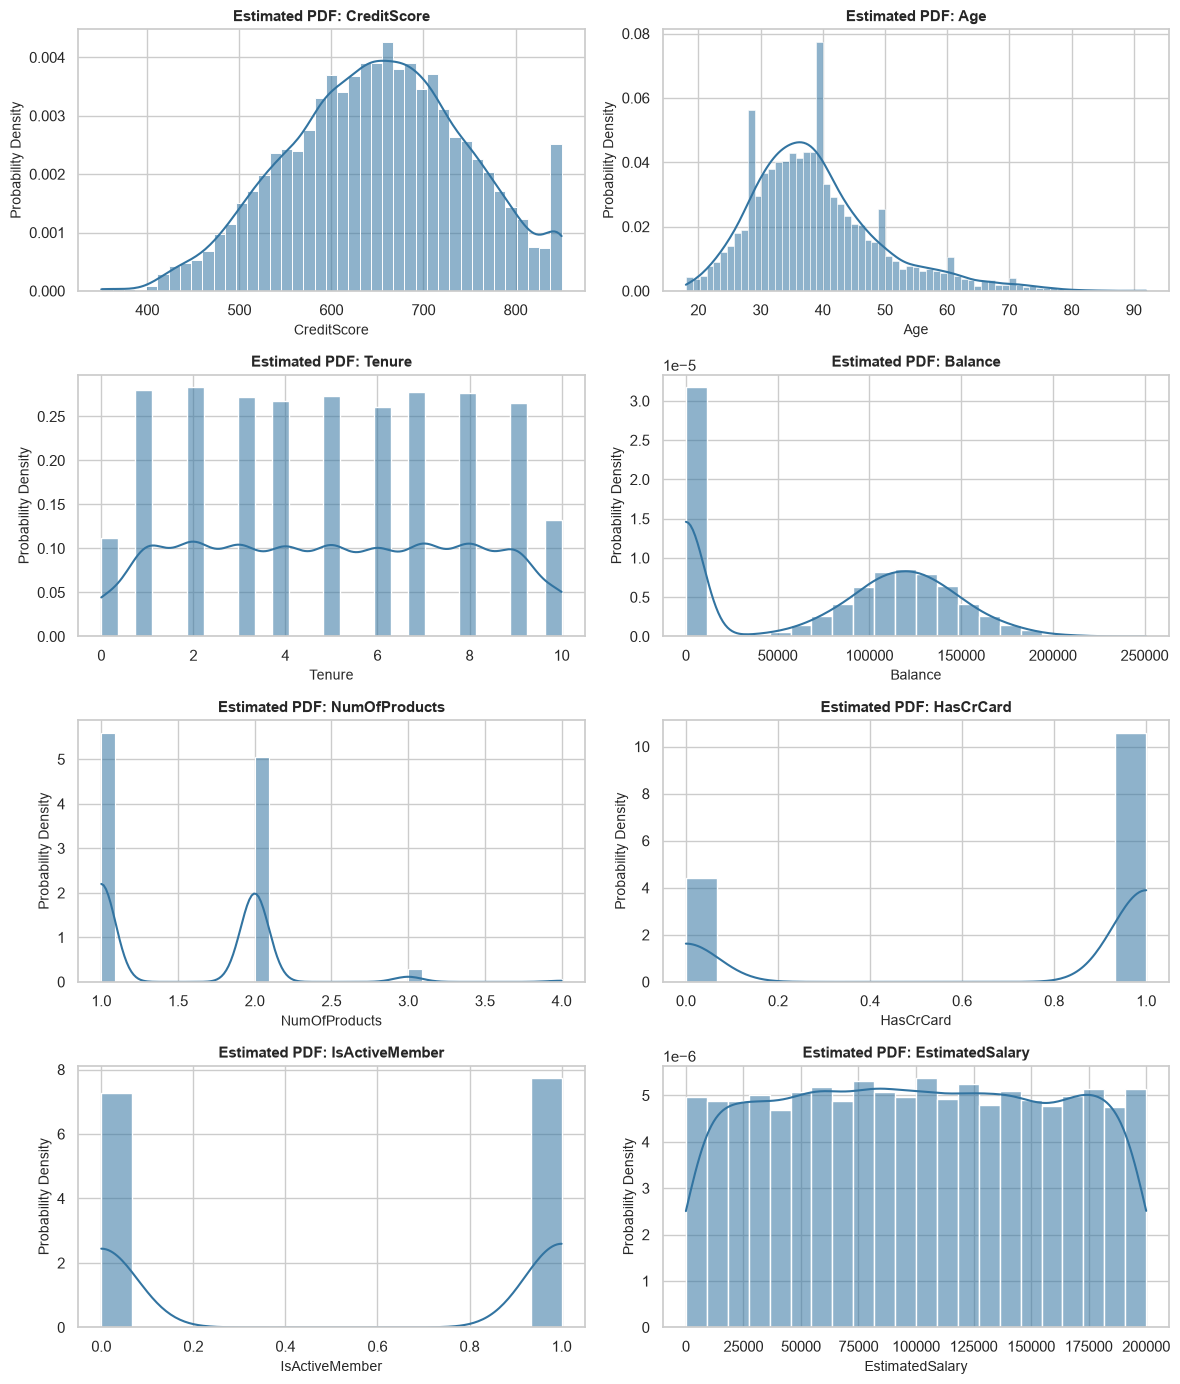

In [8]:
# Create a grid of 4 rows and 2 columns for the 8 features
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

# Loop through each numerical feature and plot its PDF
for i, col in enumerate(numerical_features):
    # Plot histogram with normalized density and smooth KDE line
    sns.histplot(df[col], kde=True, stat="density", ax=axes[i], color='#3274a1', alpha=0.55)
    
    # Set titles and axis labels
    axes[i].set_title(f"Estimated PDF: {col}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Probability Density", fontsize=10)

plt.tight_layout()
plt.show()


> **Observation (Numerical PDFs):**  
> `CreditScore` looks mostly normal (bell-shaped) centered at 650, while `Age` is right-skewed with most customers between 30 and 40. `Balance` has a large spike at zero because many customers have no balance, and `EstimatedSalary` is flat, looking like a uniform distribution.


### 3.4 Numerical Features – Empirical CDF
Empirical Cumulative Distribution Function showing cumulative probability $F_X(x) = P(X \le x)$.


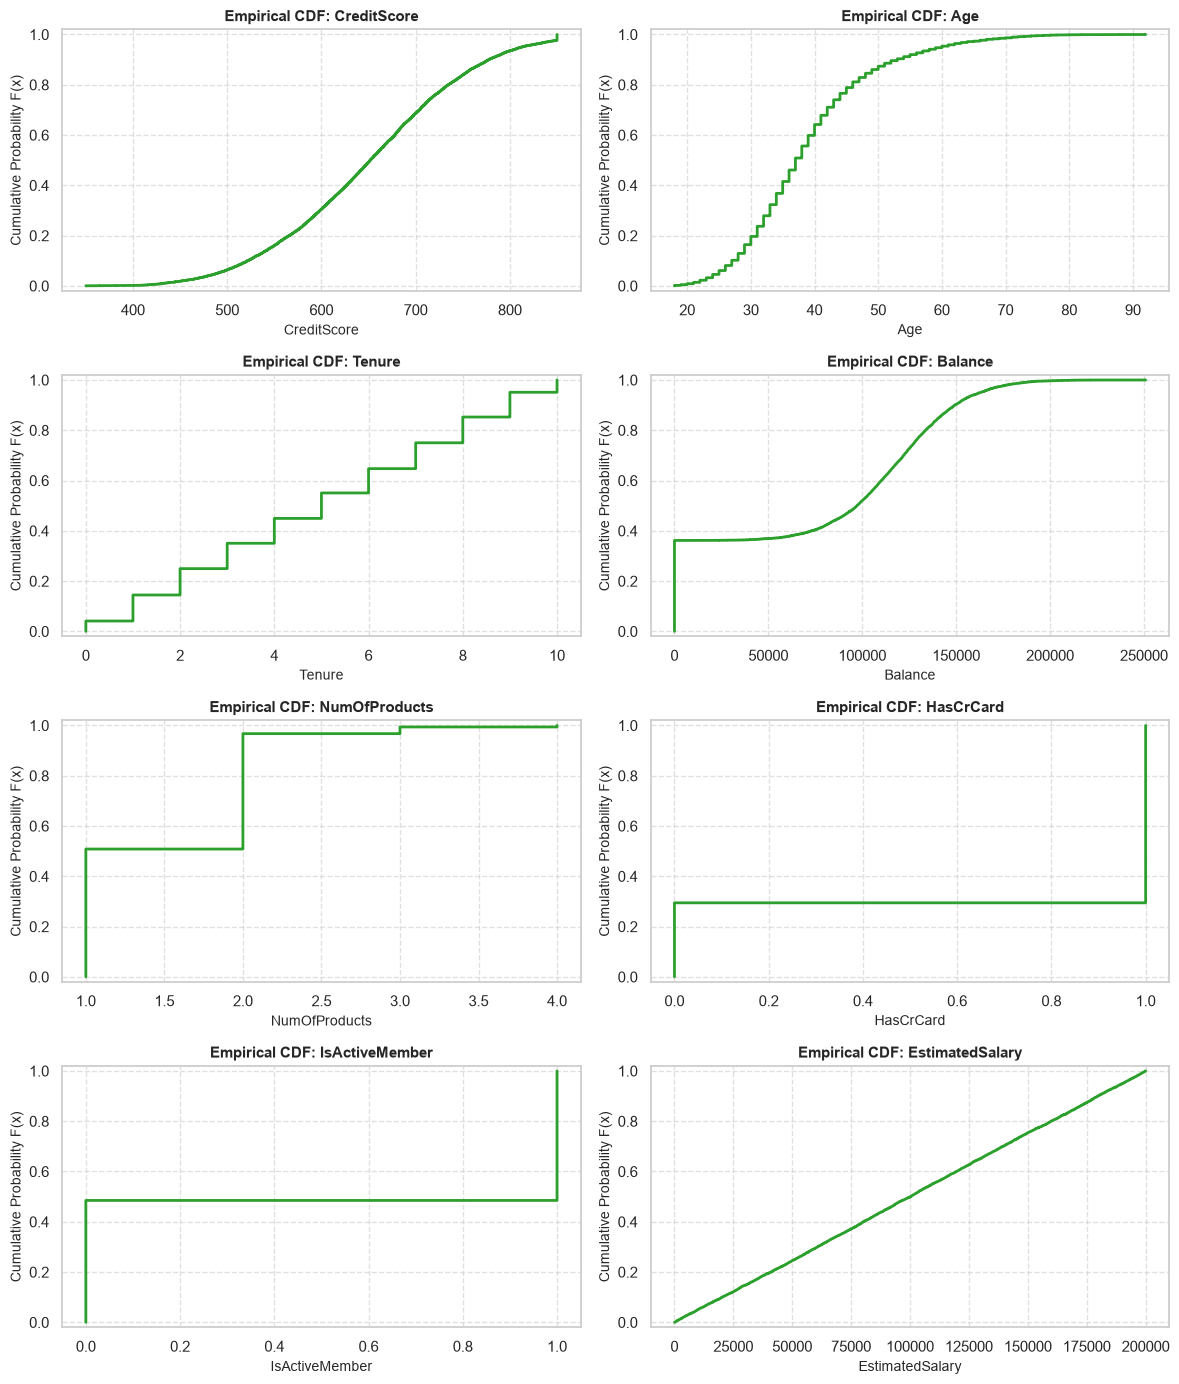

In [9]:
# Create a grid of 4 rows and 2 columns for the CDFs
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

# Loop through each numerical feature and plot its empirical CDF
for i, col in enumerate(numerical_features):
    # Sort the data values from smallest to largest
    sorted_values = np.sort(df[col])
    
    # Calculate cumulative probability: 1/N, 2/N, ..., N/N
    cumulative_prob = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    
    # Step plot for empirical CDF
    axes[i].step(sorted_values, cumulative_prob, where='post', color='#2ca02c', linewidth=2)
    
    # Set titles and axis labels
    axes[i].set_title(f"Empirical CDF: {col}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Cumulative Probability F(x)", fontsize=10)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


> **Observation (Empirical CDFs):**  
> The CDF for `Balance` shows an immediate vertical jump at zero up to ~36%, proving that more than a third of accounts have zero balance. `EstimatedSalary` forms a straight diagonal line, which is typical for a uniform distribution, while `CreditScore` and `Age` show smooth S-curves.


## 4. Basic Preprocessing Pipeline (Follow Strict Rules)

We follow the 4 required steps in order:
1. Remove exact duplicate rows.
2. Remove rows where the target is missing.
3. Impute missing numerical values using the median.
4. One-hot encode categorical features and encode the target labels as integers.

*Note: We keep `df` as the original dataset and store the cleaned version in `cleaned_df`.*


In [10]:
# Make a copy of the dataset so the original remains untouched
cleaned_df = df.copy()

# Step 1: Remove exact duplicate rows
before_dup = len(cleaned_df)
cleaned_df = cleaned_df.drop_duplicates()
print(f"Step 1: Removed {before_dup - len(cleaned_df)} duplicate rows.")

# Step 2: Remove rows where the target column (Exited) is missing
before_na = len(cleaned_df)
cleaned_df = cleaned_df.dropna(subset=['Exited'])
print(f"Step 2: Removed {before_na - len(cleaned_df)} rows with missing target.")

# Step 3: Fill missing numerical values with the feature median
imputed_count = 0
for col in numerical_features:
    if cleaned_df[col].isnull().sum() > 0:
        median_val = cleaned_df[col].median()
        cleaned_df[col] = cleaned_df[col].fillna(median_val)
        imputed_count += 1
print(f"Step 3: Missing numerical values filled using median. Features imputed: {imputed_count}")

# Drop ID-like columns that are not useful for machine learning
id_cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
cleaned_df = cleaned_df.drop(columns=id_cols_to_drop)
print(f"Dropped ID columns: {id_cols_to_drop}")

# Step 4: One-hot encode categorical input features and encode target
# Target is already 0 and 1, ensure integer type
cleaned_df['Exited'] = cleaned_df['Exited'].astype(int)

# One-hot encode Geography and Gender
categorical_cols = ['Geography', 'Gender']
cleaned_df = pd.get_dummies(cleaned_df, columns=categorical_cols, dtype=int)

# Print the encoding mapping dictionary
print("\nEncoding Mapping:")
print("- Target 'Exited': 0 = Stayed (Retained), 1 = Left (Churned)")
print("- Geography -> One-hot encoded into Geography_France, Geography_Germany, Geography_Spain")
print("- Gender -> One-hot encoded into Gender_Female, Gender_Male")

# Print final shape
print(f"\nFinal Cleaned Dataset Shape: {cleaned_df.shape[0]} rows, {cleaned_df.shape[1]} columns")

# Display first 5 rows of the cleaned data
display(cleaned_df.head())

# Save cleaned dataset to CSV
cleaned_df.to_csv("Hloz_M1_Cleaned.csv", index=False)
print("Saved cleaned data to 'Hloz_M1_Cleaned.csv'!")


Step 1: Removed 0 duplicate rows.
Step 2: Removed 0 rows with missing target.
Step 3: Missing numerical values filled using median. Features imputed: 0
Dropped ID columns: ['RowNumber', 'CustomerId', 'Surname']

Encoding Mapping:
- Target 'Exited': 0 = Stayed (Retained), 1 = Left (Churned)
- Geography -> One-hot encoded into Geography_France, Geography_Germany, Geography_Spain
- Gender -> One-hot encoded into Gender_Female, Gender_Male

Final Cleaned Dataset Shape: 10000 rows, 14 columns


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


Saved cleaned data to 'Hloz_M1_Cleaned.csv'!


### 3.5 Correlation Heatmap (After Preprocessing)
Correlation matrix and heatmap for the numerical input features after preprocessing.


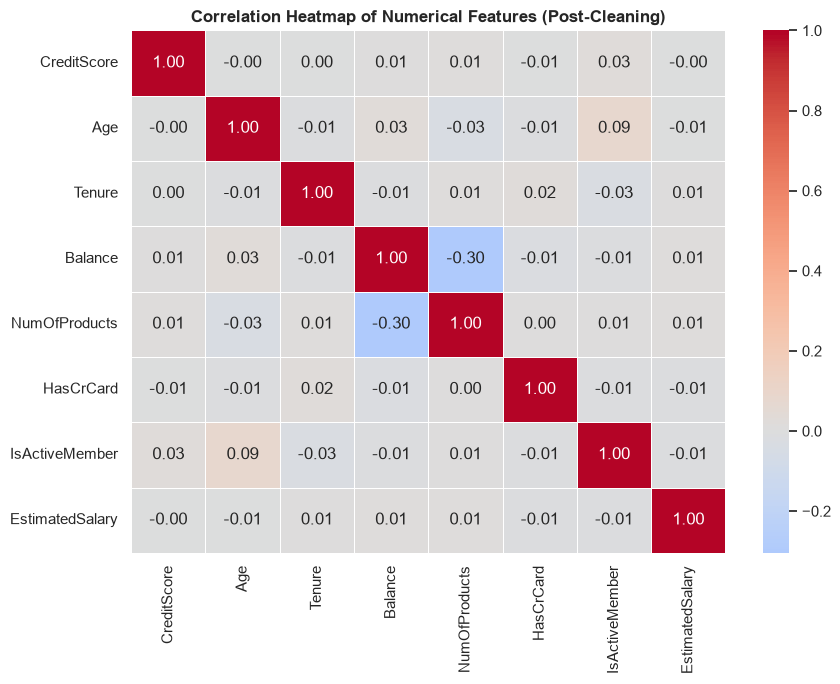

In [11]:
# Calculate Pearson correlation between numerical features
plt.figure(figsize=(9, 7))
corr_matrix = cleaned_df[numerical_features].corr()

# Draw heatmap with correlation values rounded to 2 decimal places
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)

# Set title
plt.title("Correlation Heatmap of Numerical Features (Post-Cleaning)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation (Correlation Heatmap):**  
> Most numerical features have very low correlation with each other (close to 0). The only noticeable correlation is between `Balance` and `NumOfProducts` (-0.30), meaning customers with more products tend to have lower account balances. Since correlations are low, multicollinearity won't be an issue for model training.


## 5. Milestone 1 Conclusion (Summary of Learnings)
- **Data Quality:** The dataset is complete with 10,000 rows, zero duplicate rows, and zero missing values across all columns.
- **Target Imbalance:** About 79.6% of customers stayed and 20.4% left, showing a moderate class imbalance.
- **Distributions:** `CreditScore` is bell-shaped, `Age` is skewed towards older customers, `EstimatedSalary` is uniform, and `Balance` has a large spike at 0 (zero-inflated).
- **Preprocessing:** We removed 3 useless ID columns (`RowNumber`, `CustomerId`, `Surname`) and one-hot encoded `Geography` and `Gender`.
- **Output:** The final cleaned dataset `Hloz_M1_Cleaned.csv` has 10,000 rows and 14 clean numerical columns, ready for Milestone 2.
